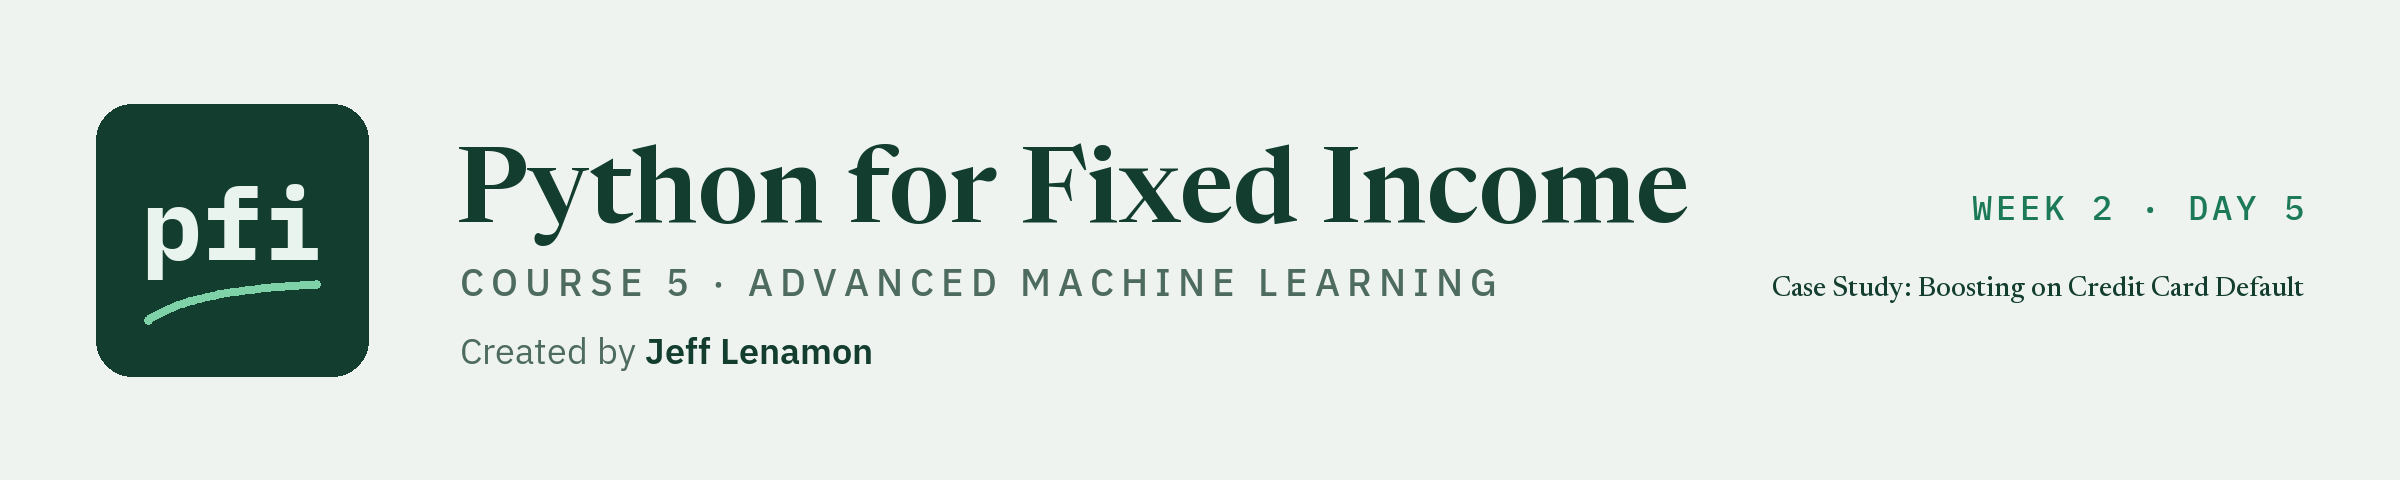

# Case Study: Boosting on Credit Card Default

Week 2, Day 5. Week 2 ends with a case study: six models on the card file, each with its settings and threshold chosen inside the training rows, compared on the validation rows with bootstrap intervals, and a written description of what the chosen model shows and where it fails. The test rows stay closed.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week2/day5/10_case_study_boosting_on_credit_card_default.ipynb)

Course 4 ended its week 2 with a case study on this file and opened its test rows, once, at the end. Course 5's week 2 ends with a case study on the same file, with the ensembles of weeks 1 and 2 beside Course 4's two models, and it opens nothing. The question a colleague asks is the same; the honest answer has one more part: **when the models are this close, how much of the difference between them is noise from which rows happened to be scored?**

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file Course 1 described in notebook 16 and Course 4 modelled in week 2. The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are in no model, and no output is grouped by them. Every model today uses the other 19 columns.
* **Course 4's split, rebuilt, with its test rows closed.** The case study is where a test set is usually opened, so the rule is quoted here in full:

**The test-row rule.** Course 4 opened its 6,000 card test rows once, on day 10, and reported on them. Scoring them again for a new round of models, after their numbers have been seen, would turn them into rows the course chooses against, so Course 5 never scores them. `ensemblekit.course4_card_rows` rebuilds Course 4's split with the same two calls and the same seed and returns only the training and validation rows, so a closed row cannot be scored by accident. The validation rows were used in Course 4 to choose a threshold and a pruning level, never to fit; Course 5 chooses nothing on them. Settings are chosen inside the training rows, and the validation rows report, labelled validation, never test.

* **A model's output is described, never acted on.** A model's output is the model probability of default in this file, or a flag at a threshold; Course 4's pruned tree, fitted with class weights, gives the model's score. No output of either kind is a credit decision for any person.

The day has two halves.

**Hands-on, sections 10.1 and 10.2.**

1. `bootstrap_interval`: how far a validation ROC AUC moves when the scored rows are resampled, for two boosters; then the same resamples by hand, for the difference between them.
2. `compare_models` on the validation rows, with thresholds chosen from out-of-fold probabilities on the training rows.

**Case study, sections 10.3 to 10.11.** Course 4's logistic regression and pruned tree, a random forest, XGBoost, LightGBM, and a LightGBM tuned by a small randomized search, every one fitted and chosen on the training rows; the comparison on validation rows with intervals; the chosen model's importance table; a three-sheet results workbook; and **What the Model Shows, and Where It Fails**.

Q. Set up today's work folder: the thread settings, the seed, the card file, and the files the tests read.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_10_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_10_k9f0vn71, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)


from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


def test_boost_by_hand_matches_sklearn():
    train = bench_rows()
    X, y = train[["score", "duration", "years"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=100, learning_rate=0.1, max_depth=2)
    library = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=SEED).fit(X, y)
    assert fitted == pytest.approx(library.predict(X), abs=1e-12)


def test_boost_by_hand_one_round_is_mean_plus_stump():
    train = bench_rows()
    X, y = train[["score"]], train["log_oas"]
    fitted = ensemblekit.boost_by_hand(X, y, n_rounds=1, learning_rate=0.5, max_depth=1)
    stump = DecisionTreeRegressor(max_depth=1, random_state=SEED).fit(X, y - y.mean())
    assert fitted == pytest.approx(y.mean() + 0.5 * stump.predict(X), abs=1e-12)
    # a stump has two leaves, so one round gives two distinct fitted values
    assert len(np.unique(fitted.round(12))) == 2
    with pytest.raises(ValueError):
        ensemblekit.boost_by_hand(X, y, n_rounds=0, learning_rate=0.1, max_depth=1)


def test_mae_bp_hand():
    # spreads of 100 and 200 bp fitted at 110 and 180 bp: errors 10 and 20 bp
    log_true, log_fitted = np.log([100.0, 200.0]), np.log([110.0, 180.0])
    assert ensemblekit.mae_bp(log_true, log_fitted) == pytest.approx(15.0, abs=1e-9)
    with pytest.raises(ValueError):
        ensemblekit.mae_bp([1.0], [1.0, 2.0])


def test_early_stopping_rows_stratified_and_disjoint():
    X_train, X_valid, y_train, _ = card_rows()
    X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
    assert (len(X_fit), len(X_stop)) == (14_400, 3_600)
    assert not set(X_fit.index) & set(X_stop.index)
    # the stopping rows come from the training rows, never from the validation rows
    assert set(X_stop.index) <= set(X_train.index)
    assert not set(X_stop.index) & set(X_valid.index)
    assert abs(y_stop.mean() - y_train.mean()) < 0.001


def test_early_stopping_rows_rejects_fraction():
    X, y = card_small(500)
    for fraction in (0.0, 0.5, 0.8):
        with pytest.raises(ValueError):
            ensemblekit.early_stopping_rows(X, y, fraction=fraction)


def test_scale_pos_weight_hand():
    assert ensemblekit.scale_pos_weight([0, 0, 0, 1]) == pytest.approx(3.0, abs=1e-12)
    assert ensemblekit.scale_pos_weight(pd.Series([1, 0, 1, 0, 0, 0])) == pytest.approx(2.0, abs=1e-12)


def test_scale_pos_weight_rejects_no_positive():
    with pytest.raises(ValueError):
        ensemblekit.scale_pos_weight([0, 0, 0])


from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_predict


def base_models() -> dict:
    return {"logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
            "tree": DecisionTreeClassifier(max_depth=3, random_state=SEED)}


def test_stack_inputs_match_cross_val_predict():
    X, y = card_small()
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    for name, model in base_models().items():
        direct = cross_val_predict(model, X, y, cv=ensemblekit.mlkit.cv_folds(), method="predict_proba", n_jobs=1)
        assert inputs[name].to_numpy() == pytest.approx(direct[:, 1], abs=1e-12)


def test_stack_inputs_columns_named():
    X, y = card_small(1_000)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    assert list(inputs.columns) == ["logistic", "tree"]
    assert inputs.index.equals(X.index)
    with pytest.raises(ValueError):
        ensemblekit.stack_inputs({}, X, y)


def test_stacking_classifier_uses_out_of_fold():
    X, y = card_small()
    stack = StackingClassifier(list(base_models().items()), final_estimator=LogisticRegression(),
                               stack_method="predict_proba", cv=ensemblekit.mlkit.cv_folds(), n_jobs=1).fit(X, y)
    inputs = ensemblekit.stack_inputs(base_models(), X, y)
    by_hand = LogisticRegression().fit(inputs.to_numpy(), y)
    assert stack.final_estimator_.coef_ == pytest.approx(by_hand.coef_, abs=1e-10)
    assert stack.final_estimator_.intercept_ == pytest.approx(by_hand.intercept_, abs=1e-10)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold', 'samme_alpha', 'reweight', 'boost_by_hand', 'mae_bp', 'early_stopping_rows', 'scale_pos_weight', 'stack_inputs']


* The setup wrote `mlkit.py` and the module as day 9 left it, with its tests. The benchmark and ratings files are there only because day 5's tests read them.

## 10.1 How Much of a Difference Is Noise

In today's case study the ensembles land within a few thousandths of ROC AUC of each other on the validation rows. Before comparing them, the question to settle is how much a validation ROC AUC moves for a reason that has nothing to do with the model: which 6,000 accounts happened to be the validation rows.

The **bootstrap** of day 1 answers it, applied this time to the scored rows rather than the training rows. Resample the validation rows with replacement, score the same fitted model on each resample, and look at how the ROC AUC spreads. Nothing is refitted.

Q. Add `bootstrap_interval` to `ensemblekit.py`. Read the docstring first.

In [6]:
%%writefile -a ensemblekit.py


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)

Appending to ensemblekit.py


* The interval is the 2.5th and 97.5th percentiles of the resampled metric (`level=0.95`), with numpy's default linear method. The docstring says what it describes: the noise from **which rows happened to be scored**, not the noise from refitting the model on other training rows.
* A resample with one class has no ROC AUC, so the function draws it again. On 6,000 validation rows with over a thousand defaults that never happens; on a small set of rows it does, and the third test makes it happen.

Q. Add its three tests: the interval contains the point estimate, the seed fixes it, and a one-class resample is drawn again.

In [7]:
%%writefile -a test_ensemblekit.py


def validation_scores(n: int = 2_000) -> tuple[pd.Series, np.ndarray]:
    """Outcomes and probabilities of a depth-3 tree, fitted on 3,000 training rows, on n validation rows."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X, y)
    return y_valid.iloc[:n], tree.predict_proba(X_valid.iloc[:n])[:, 1]


def test_bootstrap_interval_contains_point():
    y, proba = validation_scores()
    lower, upper = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=200)
    assert lower < roc_auc_score(y, proba) < upper
    assert upper - lower < 0.1


def test_bootstrap_interval_seeded():
    y, proba = validation_scores(500)
    first = ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first == ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=SEED)
    assert first != ensemblekit.bootstrap_interval(y, proba, roc_auc_score, n_boot=100, seed=7)


def test_bootstrap_interval_redraws_one_class_resample():
    # one positive in five rows: about a third of the resamples hold no positive and must be drawn again
    y, proba = np.array([0, 0, 0, 0, 1]), np.array([0.1, 0.2, 0.3, 0.4, 0.9])

    def strict_auc(actual, scores):
        assert len(np.unique(actual)) == 2, "a resample with one class reached the metric"
        return roc_auc_score(actual, scores)

    lower, upper = ensemblekit.bootstrap_interval(y, proba, strict_auc, n_boot=50)
    assert lower == upper == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_interval(np.zeros(5), proba, roc_auc_score)

Appending to test_ensemblekit.py


Q. Reload the module and run the tests.

In [8]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"bootstrap_interval in ensemblekit: {hasattr(ensemblekit, 'bootstrap_interval')}")

bootstrap_interval in ensemblekit: True


In [9]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# past one minute pytest adds the run time again as h:mm:ss in brackets; run times differ every run, so it is left out
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

......................................                                   [100%]
38 passed in 14.79s



* `38 passed`: day 9's 35 and today's three. The third test scores five rows with one default, so about a third of its resamples hold no default: a strict metric would fail on any of them, and it never sees one.

Q. Load Course 4's card rows. Fit XGBoost with day 8's settings and LightGBM with day 9's on the training rows, and score both on the validation rows.

In [10]:
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

# day 8's XGBoost and day 9's LightGBM, each written with n_jobs=1 and the seed
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                    random_state=SEED, n_jobs=1)
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=1, verbose=-1)
xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)

# each model's probability of default in this file, on every validation account
proba_xgb = xgb.predict_proba(X_valid)[:, 1]
proba_lgb = lgb.predict_proba(X_valid)[:, 1]
for name, proba in [("XGBoost", proba_xgb), ("LightGBM", proba_lgb)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba):.4f}, "
          f"average precision {average_precision_score(y_valid, proba):.4f}")

XGBoost: validation ROC AUC 0.7794, average precision 0.5447
LightGBM: validation ROC AUC 0.7725, average precision 0.5434


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows, chooses its settings and its threshold by cross-validation inside them, and is scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* Both outputs are the model probability of default in this file. XGBoost ranks the validation accounts at 0.7794 and LightGBM at 0.7725: a gap of 0.0069. Is that a difference between the models, or between the rows?

Q. Put a 95 percent bootstrap interval on each model's validation ROC AUC.

In [11]:
# 1,000 resamples of the validation rows, seeded; the fitted models are only scored, never refitted
interval_xgb = ensemblekit.bootstrap_interval(y_valid, proba_xgb, roc_auc_score)
interval_lgb = ensemblekit.bootstrap_interval(y_valid, proba_lgb, roc_auc_score)
for name, proba, (low, high) in [("XGBoost", proba_xgb, interval_xgb), ("LightGBM", proba_lgb, interval_lgb)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba):.4f}, 95 percent interval {low:.4f} to {high:.4f}")

XGBoost: validation ROC AUC 0.7794, 95 percent interval 0.7650 to 0.7933
LightGBM: validation ROC AUC 0.7725, 95 percent interval 0.7572 to 0.7871


* XGBoost 0.7650 to 0.7933; LightGBM 0.7572 to 0.7871. Each interval is about 0.028 wide, several times the 0.0069 gap, and the two overlap almost entirely. A different draw of 6,000 validation accounts could easily have put either model's ROC AUC a hundredth higher or lower.
* Two overlapping intervals do not settle the question, though. Both models were scored on **the same** rows, so a resample that happens to be easy is easy for both: their ROC AUCs move together. The fair question is how the **difference** moves.

Q. Draw the same 1,000 resamples by hand, score both models on each, and put an interval on the difference.

In [12]:
# bootstrap_interval's own steps, written out, for both models on each resample
y_array = y_valid.to_numpy()
rng = np.random.default_rng(SEED)
resampled = {"xgboost": [], "lightgbm": []}
while len(resampled["xgboost"]) < 1000:
    rows = rng.integers(0, len(y_array), len(y_array))
    # the function's rule: a resample with one class is drawn again
    if len(np.unique(y_array[rows])) < 2:
        continue
    resampled["xgboost"].append(roc_auc_score(y_array[rows], proba_xgb[rows]))
    resampled["lightgbm"].append(roc_auc_score(y_array[rows], proba_lgb[rows]))
aucs = pd.DataFrame(resampled)
aucs["difference"] = aucs["xgboost"] - aucs["lightgbm"]

# the same seed and the same rule, so the same 1,000 resamples: bootstrap_interval's interval comes back
same = np.allclose(np.percentile(aucs["xgboost"], [2.5, 97.5]), interval_xgb, rtol=0, atol=1e-12)
diff_low, diff_high = np.percentile(aucs["difference"], [2.5, 97.5])
print(f"XGBoost's interval from the hand loop equals bootstrap_interval's within 1e-12: {same}")
print(f"difference XGBoost minus LightGBM: 95 percent interval {diff_low:.4f} to {diff_high:.4f}")
print(f"resamples on which XGBoost ranks higher: {(aucs['difference'] > 0).mean():.1%}")

XGBoost's interval from the hand loop equals bootstrap_interval's within 1e-12: True
difference XGBoost minus LightGBM: 95 percent interval 0.0025 to 0.0111
resamples on which XGBoost ranks higher: 99.9%


* The hand loop is `bootstrap_interval` with its steps visible, and it gives the function's interval back exactly: the same seed draws the same resamples.
* The difference moves far less than either ROC AUC does, because the two models rise and fall together: the paired interval is 0.0086 wide against 0.0282 for one model. The paired interval, 0.0025 to 0.0111, lies above zero: on these rows the gap is larger than the noise from resampling them, and XGBoost ranks higher on 99.9 percent of the resamples. That is a statement about these two fitted models on these rows. It says nothing about refitting them: another seed for XGBoost's row and column sampling would give another fitted model, and the interval does not cover that.
* So the honest way to compare two models scored on the same rows is the paired difference, not two separate intervals. The case study does both: a separate interval on every model, as a measure of how far each number can move, then the paired difference between the chosen model and each of the others.

## 10.2 `compare_models` With Out-of-Fold Thresholds

A ROC AUC compares rankings. A desk that uses a model at all uses it at a threshold. Course 4's rule takes the highest threshold whose recall is at least 0.70; Course 5 applies it to **out-of-fold probabilities on the training rows** (`oof_threshold`, day 5), so the validation rows choose nothing, not even a threshold.

Q. Choose each booster's threshold inside the training rows, then report both on the validation rows with `compare_models`.

In [13]:
# five folds of the training rows: each row's probability from the fold model that did not see it, then the rule
threshold_xgb, oof_xgb = ensemblekit.oof_threshold(xgb, X_train, y_train)
threshold_lgb, oof_lgb = ensemblekit.oof_threshold(lgb, X_train, y_train)

# the validation rows report: compare_models fits nothing
two = mlkit.compare_models({"xgboost": xgb, "lightgbm": lgb}, X_valid, y_valid,
                           {"xgboost": threshold_xgb, "lightgbm": threshold_lgb})
print(two.round(4).to_string())

          roc_auc  average_precision  threshold  accuracy  precision  recall      f1
xgboost    0.7794             0.5447     0.1812    0.7133     0.4115  0.6888  0.5152
lightgbm   0.7725             0.5434     0.1778    0.7060     0.4043  0.6956  0.5114


* The thresholds, 0.1812 for XGBoost and 0.1778 for LightGBM, are the highest at which each model's out-of-fold recall on the training rows is at least 0.70. On the validation rows the recall lands at 0.6888 and 0.6956: near 0.70, not on it, because a threshold set on one set of rows is not a guarantee on another. Nothing is moved to make it 0.70; moving it now would be choosing on the validation rows.
* Flagged at those thresholds, 41.2 percent and 40.4 percent of the flagged validation accounts defaulted. The flags are the model's output at a threshold, a description of this file; no flag is a credit decision for any person.

## Case Study: Boosting on Credit Card Default

### Context

Course 1 described this file without a model. Course 4 fitted a logistic regression and a pruned tree to it, chose among them on the validation rows, and reported on the test rows once. Weeks 1 and 2 of Course 5 have since fitted bagging, forests, AdaBoost, gradient boosting, XGBoost, and LightGBM to the same 18,000 training rows. A colleague asks the question this case study answers: **which of these models separates the accounts that defaulted from those that did not best on accounts it never saw, by how much, and where does the chosen one fail?**

The answer is a description of a historical dataset. It is not a lending rule, it ranks no person, and it says nothing about what anyone should do.

### Objective

1. Fit six models on the training rows: Course 4's logistic regression and pruned tree, a random forest, XGBoost, LightGBM, and a LightGBM tuned by a small randomized search.
2. Choose every setting, every threshold, and the model carried forward **inside the training rows**, by cross-validation and out-of-fold probabilities.
3. Report all six on the validation rows, with a bootstrap interval on each ROC AUC, and read the gaps against the intervals.
4. Describe the chosen model with its importance table, and write a three-sheet results workbook.
5. Write what the model shows, and where it fails.

**The test rows are not opened.** Course 4's case study ended by opening them; this one does not, and the reason is the test-row rule quoted at the top. Course 4 has reported on those 6,000 accounts once. A second look, for a new set of models, would make them rows the course chooses against. On this file Course 5's validation numbers play the part Course 4's test numbers did, and they are labelled validation.

### The data dictionary

Quoted from the "Additional Variable Information" section of the dataset page, as recorded in the course's `DATA.md`. Any statement about what a column means comes from this text.

> This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
> X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
> X2: Gender (1 = male; 2 = female).
> X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
> X4: Marital status (1 = married; 2 = single; 3 = others).
> X5: Age (year).
> X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
> X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005.
> X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

The file names these columns `LIMIT_BAL` (X1), `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` (X2 to X5), `PAY_0` and `PAY_2` to `PAY_6` (X6 to X11; there is no `PAY_1`), `BILL_AMT1` to `BILL_AMT6`, `PAY_AMT1` to `PAY_AMT6`, then `default payment next month`. The models read the 19 columns that are not about people.

**What the documentation leaves open**, as Course 4 found: the repayment status columns hold -2 and 0, which the page does not define. Every model reads `PAY_0` to `PAY_6` as numbers, codes included; treating the codes as ordered is a modelling choice. The page does not say how the accounts were chosen and does not name the lender.

**Place and period.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender.

## 10.3 Overview: the Rows This Course May Use

Course 1, notebook 16, described the whole file column by column, and Course 4 day 10 described it again. That work is not repeated. Course 5 describes only the rows it may use.

Q. How many accounts and defaults are in the training and validation rows, and how often do the undefined September codes appear there?

In [14]:
# the 24,000 rows Course 5 may use: training and validation, never the closed test rows
used = card.loc[X_train.index.union(X_valid.index)]
for name, outcome in [("training", y_train), ("validation", y_valid)]:
    print(f"{name}: {len(outcome):,} accounts, {outcome.sum():,} defaults, {outcome.mean():.2%}")
print(f"PAY_0 code -2: {(used['PAY_0'] == -2).sum():,} accounts; code 0: {(used['PAY_0'] == 0).sum():,} (neither is defined)")

training: 18,000 accounts, 3,982 defaults, 22.12%
validation: 6,000 accounts, 1,327 defaults, 22.12%
PAY_0 code -2: 2,198 accounts; code 0: 11,781 (neither is defined)


* 18,000 training accounts with 3,982 defaults and 6,000 validation accounts with 1,327, both 22.12 percent, because both cuts were stratified.
* 13,979 of the 24,000 accounts carry an undefined September code: 2,198 with -2 and 11,781 with 0. Every model below reads them as numbers.

## 10.4 Preparation: the Rows, Checked by Account

`course4_card_rows` returns only training and validation rows, and its closed-rows test proves it on row labels. Row labels are positions in `card`, and `ID` is unique, so the same check by account ID says the same thing in the file's own terms.

Q. Recompute Course 4's closed test rows, only to collect their account IDs, and check that no account is in two parts and none is closed.

In [15]:
from sklearn.model_selection import train_test_split

# Course 4's first call, recomputed only to name the closed rows: nothing below scores them
_, closed_rows = train_test_split(card.index, test_size=0.2, stratify=card[TARGET], random_state=SEED)
ids = {name: set(card.loc[rows, "ID"]) for name, rows in [("training", X_train.index), ("validation", X_valid.index),
                                                          ("closed", closed_rows)]}
print(f"closed test rows: {len(closed_rows):,}")
print(f"IDs in both training and validation: {len(ids['training'] & ids['validation'])}")
print(f"IDs of training or validation rows among the closed rows: {len((ids['training'] | ids['validation']) & ids['closed'])}")

closed test rows: 6,000
IDs in both training and validation: 0
IDs of training or validation rows among the closed rows: 0


* 6,000 closed rows, and no account on two sides. Preparation is otherwise inside the models: the logistic regression scales inside its pipeline, and trees need no scaling. Exercise 4 comes back to these 6,000 IDs.

## 10.5 Model Building

Five models first, each fitted on the training rows with settings from earlier days: Course 4's logistic regression and its pruned tree (day 1 reran both), a random forest of 200 trees with leaves of at least 5 rows (day 3's best leaf size, with 200 trees to keep today's run short), and the two boosters of section 10.1.

Q. Fit Course 4's two models and the forest, and collect all five models in one dictionary.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Course 4's logistic regression: scaled inside a pipeline
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
# Course 4 day 10's pruned tree: class weights, ccp_alpha chosen by five folds of the training rows
tree_search = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                           {"ccp_alpha": [0.0002, 0.0005, 0.001, 0.002, 0.005]}, cv=mlkit.cv_folds(), scoring="roc_auc", n_jobs=1)
pruned_tree = tree_search.fit(X_train, y_train).best_estimator_
# a random forest: 200 trees, leaves of at least 5 rows
forest = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=SEED, n_jobs=1).fit(X_train, y_train)

models = {"logistic": logistic, "pruned_tree": pruned_tree, "forest": forest, "xgboost": xgb, "lightgbm": lgb}
# each model scored on the rows it was fitted on: a description of the fit, never a measure of the model
for name, model in models.items():
    print(f"{name:12} ROC AUC on its own training rows {roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]):.4f}")
print(f"pruned tree: ccp_alpha {tree_search.best_params_['ccp_alpha']}, {pruned_tree.get_n_leaves()} leaves; "
      f"forest: {np.mean([tree.get_n_leaves() for tree in forest.estimators_]):,.0f} leaves per tree on average")

logistic     ROC AUC on its own training rows 0.7296
pruned_tree  ROC AUC on its own training rows 0.7691


forest       ROC AUC on its own training rows 0.9661
xgboost      ROC AUC on its own training rows 0.8496


lightgbm     ROC AUC on its own training rows 0.9220
pruned tree: ccp_alpha 0.001, 12 leaves; forest: 1,117 leaves per tree on average


* The pruned tree chooses `ccp_alpha` 0.001 again, 12 leaves. The forest's trees average 1,117 leaves each.
* On its own training rows the forest scores 0.9661, the boosters 0.8496 and 0.9220, the logistic regression 0.7296. A forest of deep trees fits its rows closely and still averages well (week 1); boosters with small trees and a learning rate fit them less closely by design (week 2). These numbers describe the fit. They measure nothing about rows the models never saw, and nothing below is chosen on them.

## 10.6 Model Improvement: a Small Randomized Search

Day 11 teaches tuning properly. Today a small search shows what tuning on the training rows looks like and what its best score does not mean. The search tries 8 settings of LightGBM, each scored by ROC AUC across the five folds of `mlkit.cv_folds()` on the training rows: 40 fits in all.

Q. Run a randomized search over three LightGBM settings, with the ranges written out.

In [17]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

# 8 settings drawn from these ranges, seeded; each scored by the mean ROC AUC over the five training folds
search = RandomizedSearchCV(LGBMClassifier(n_estimators=200, random_state=SEED, n_jobs=1, verbose=-1),
                            {"num_leaves": randint(4, 32), "learning_rate": loguniform(0.01, 0.1), "min_child_samples": randint(20, 400)},
                            n_iter=8, scoring="roc_auc", cv=mlkit.cv_folds(), random_state=SEED, n_jobs=1)
search.fit(X_train, y_train)

candidates = (pd.DataFrame(search.cv_results_["params"])
              .assign(cv_mean=search.cv_results_["mean_test_score"], cv_sd=search.cv_results_["std_test_score"])
              .sort_values("cv_mean", ascending=False, kind="stable"))
print(candidates.round(4).to_string(index=False))
print(f"best_score_ {search.best_score_:.4f}: the best of 8 fold means, on the rows that chose it")
# refit=True (the default) refits the best settings on all the training rows
models["lightgbm_tuned"] = search.best_estimator_

 learning_rate  min_child_samples  num_leaves  cv_mean  cv_sd
        0.0153                333          25   0.7837 0.0018
        0.0237                368          18   0.7837 0.0018
        0.0139                150          25   0.7836 0.0022
        0.0288                392           7   0.7829 0.0013
        0.0114                363          15   0.7825 0.0020
        0.0143                234          14   0.7823 0.0014
        0.0540                208          24   0.7782 0.0026
        0.0868                211          31   0.7699 0.0036
best_score_ 0.7837: the best of 8 fold means, on the rows that chose it


* The best settings: 25 leaves, learning rate 0.0153, at least 333 rows per leaf, each inside its range rather than at an edge. With 200 trees and a small learning rate, the model takes small steps.
* The 8 fold means span 0.0138, but the best three lie within 0.0002 of each other, far less than a typical fold standard deviation (0.0019). The search had to pick one, and among the top few the pick is close to a coin toss.
* **`best_score_` is not an honest score of the tuned model.** It is the largest of 8 noisy numbers, computed on the folds that chose it, so it leans high. Day 11 measures by how much with nested cross-validation. Here the tuned model goes to the validation rows like every other model, and they report.

## 10.7 Thresholds and the Choice, Inside the Training Rows

Six models. Each gets its threshold from `oof_threshold`, and the out-of-fold probabilities that come with it give one more thing for free: a pooled out-of-fold ROC AUC on the training rows, which can choose the model without a single validation row.

Q. Run `oof_threshold` for the four models that do not have one yet, put the thresholds and pooled out-of-fold scores in one table, and choose the model with the highest pooled out-of-fold ROC AUC.

In [18]:
# out-of-fold probabilities and thresholds: the two boosters' from section 10.2, the other four now
oof = {"xgboost": oof_xgb, "lightgbm": oof_lgb}
thresholds = {"xgboost": threshold_xgb, "lightgbm": threshold_lgb}
for name, model in models.items():
    if name not in oof:
        thresholds[name], oof[name] = ensemblekit.oof_threshold(model, X_train, y_train)

# pooled over the five folds: one probability per training row, each from a model that did not see the row
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "oof_roc_auc": {name: roc_auc_score(y_train, proba) for name, proba in oof.items()},
    "oof_average_precision": {name: average_precision_score(y_train, proba) for name, proba in oof.items()},
}).loc[list(models)]
chosen = threshold_table["oof_roc_auc"].idxmax()
print(threshold_table.round(4).to_string())
print(f"chosen on pooled out-of-fold ROC AUC, training rows only: {chosen}")

                threshold  oof_roc_auc  oof_average_precision
logistic           0.2047       0.7273                 0.5084
pruned_tree        0.4015       0.7603                 0.5112
forest             0.1987       0.7754                 0.5503
xgboost            0.1812       0.7797                 0.5542
lightgbm           0.1778       0.7743                 0.5483
lightgbm_tuned     0.1890       0.7832                 0.5488
chosen on pooled out-of-fold ROC AUC, training rows only: lightgbm_tuned


* The tuned LightGBM has the highest pooled out-of-fold ROC AUC, 0.7832, 0.0035 above the XGBoost (0.7797). It is carried forward to the importance table and the description. By out-of-fold average precision the XGBoost is first (0.5542): the two measures do not agree on the order at the top, another sign of how close the ensembles are.
* Two of these numbers lean high. The tuned LightGBM's settings and the pruned tree's `ccp_alpha` were chosen on these same five folds, so their out-of-fold scores carry a little of the search's luck. The choice is made anyway, as a desk would make it, with the lean said out loud; the validation rows, which chose nothing, report next.
* These are pooled out-of-fold scores (one probability per row, scored together), not the mean of five fold scores that `best_score_` reports. The two differ, and the text never mixes them.

## 10.8 Comparison on Validation Rows, With Intervals

Every choice is made: settings, thresholds, and the model carried forward. Now the validation rows report, and each ROC AUC gets its bootstrap interval.

Q. Run `compare_models` on the validation rows at the out-of-fold thresholds, and add a 95 percent interval to each model's ROC AUC.

In [19]:
# the validation rows report: nothing is fitted or chosen here
valid_table = mlkit.compare_models(models, X_valid, y_valid, thresholds)

# the two boosters' intervals from section 10.1, the other four now: the same 1,000 resamples for every model
intervals = {"xgboost": interval_xgb, "lightgbm": interval_lgb}
for name, model in models.items():
    if name not in intervals:
        intervals[name] = ensemblekit.bootstrap_interval(y_valid, model.predict_proba(X_valid)[:, 1], roc_auc_score)
interval_table = pd.DataFrame(intervals, index=["lower", "upper"]).T.loc[list(models)]
interval_table.insert(0, "roc_auc", valid_table["roc_auc"])

print(valid_table.round(4).to_string())
print()
print(interval_table.round(4).to_string())
print(f"all-zero baseline accuracy on the validation rows: {1 - y_valid.mean():.4f}")

                roc_auc  average_precision  threshold  accuracy  precision  recall      f1
logistic         0.7190             0.4946     0.2047    0.6230     0.3319  0.6956  0.4494
pruned_tree      0.7627             0.4954     0.4015    0.6773     0.3788  0.7174  0.4958
forest           0.7814             0.5450     0.1987    0.7123     0.4113  0.6971  0.5173
xgboost          0.7794             0.5447     0.1812    0.7133     0.4115  0.6888  0.5152
lightgbm         0.7725             0.5434     0.1778    0.7060     0.4043  0.6956  0.5114
lightgbm_tuned   0.7830             0.5513     0.1890    0.7235     0.4232  0.6895  0.5245

                roc_auc   lower   upper
logistic         0.7190  0.7010  0.7352
pruned_tree      0.7627  0.7476  0.7784
forest           0.7814  0.7673  0.7948
xgboost          0.7794  0.7650  0.7933
lightgbm         0.7725  0.7572  0.7871
lightgbm_tuned   0.7830  0.7680  0.7968
all-zero baseline accuracy on the validation rows: 0.7788


* On the validation rows the tuned LightGBM ranks highest, 0.7830 (0.7680 to 0.7968). The tuned LightGBM was also the model chosen inside the training rows; with gaps this small, that agreement is partly luck. The four ensembles lie between 0.7725 and 0.7830, a spread of 0.0105, and every ensemble's interval overlaps every other's.
* Course 4's logistic regression, 0.7190 (0.7010 to 0.7352), lies below every ensemble, and its interval ends below where every ensemble's begins. Course 4's pruned tree, 0.7627 (0.7476 to 0.7784), sits between them, and its interval reaches into every ensemble's.
* Recall at the out-of-fold thresholds runs from 0.6888 to 0.7174 on the validation rows; 5 of the six land below 0.70. Accuracy sits beside the all-zero baseline (0.7788), which flags no account, and chose nothing.

Q. Draw each model's validation ROC AUC with its interval.

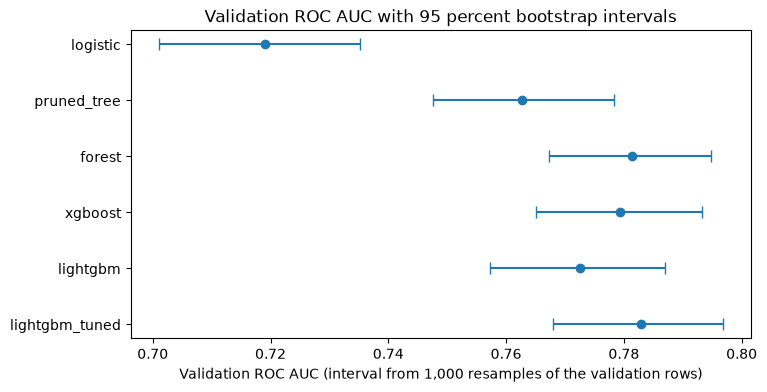

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
names = list(interval_table.index)
positions = np.arange(len(names))
# a bar from the lower to the upper end of each interval, and the validation ROC AUC as a dot
ax.errorbar(interval_table["roc_auc"], positions,
            xerr=[interval_table["roc_auc"] - interval_table["lower"], interval_table["upper"] - interval_table["roc_auc"]],
            fmt="o", capsize=4)
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_title("Validation ROC AUC with 95 percent bootstrap intervals")
ax.set_xlabel("Validation ROC AUC (interval from 1,000 resamples of the validation rows)")
plt.show()

* The four ensembles' bars sit on top of one another, the pruned tree's reaches into them, and the logistic regression's is clear of all of them.
* Section 10.1 showed what separate intervals miss: every model here was scored on the same rows, so their ROC AUCs rise and fall together. The paired difference is the sharper test.

Q. Put a paired interval on the difference between the chosen model and each of the other five, on the same 1,000 resamples.

In [21]:
# section 10.1's loop for six models: the chosen model minus each other model, on each resample
others = [name for name in models if name != chosen]
proba_valid = {name: model.predict_proba(X_valid)[:, 1] for name, model in models.items()}
rng = np.random.default_rng(SEED)
differences = {name: [] for name in others}
while len(differences[others[0]]) < 1000:
    rows = rng.integers(0, len(y_array), len(y_array))
    if len(np.unique(y_array[rows])) < 2:
        continue
    chosen_auc = roc_auc_score(y_array[rows], proba_valid[chosen][rows])
    for name in others:
        differences[name].append(chosen_auc - roc_auc_score(y_array[rows], proba_valid[name][rows]))

paired = pd.DataFrame({name: np.percentile(values, [2.5, 97.5]) for name, values in differences.items()},
                      index=["lower", "upper"]).T
paired.insert(0, "difference", [valid_table.loc[chosen, "roc_auc"] - valid_table.loc[name, "roc_auc"] for name in others])
paired["chosen_higher_share"] = [np.mean(np.array(differences[name]) > 0) for name in others]
print(f"validation ROC AUC of {chosen} minus each model, 95 percent paired intervals:")
print(paired.round(4).to_string())

validation ROC AUC of lightgbm_tuned minus each model, 95 percent paired intervals:
             difference   lower   upper  chosen_higher_share
logistic         0.0639  0.0509  0.0769                1.000
pruned_tree      0.0203  0.0123  0.0279                1.000
forest           0.0016 -0.0040  0.0070                0.710
xgboost          0.0036 -0.0006  0.0079                0.948
lightgbm         0.0105  0.0053  0.0153                1.000


* Paired, the tuned LightGBM's lead is larger than the resampling noise against the logistic regression, the pruned tree and the LightGBM: each of those paired intervals lies above zero. Against the random forest and the XGBoost it is not: random forest -0.0040 to 0.0070, XGBoost -0.0006 to 0.0079, each reaching below zero, with the chosen model ahead on 71 percent and 95 percent of the resamples.
* The pruned tree shows the difference between the two tests. Alone, its interval reaches into every ensemble's. Paired, its gap to the chosen model, 0.0203, has an interval of 0.0123 to 0.0279, clear of zero.
* What tuning bought: the search's LightGBM sits 0.0105 above the default LightGBM, a gap these rows separate. Over the forest and XGBoost, fitted with settings from earlier days and no search, these rows show no gain they can separate.
* Every interval here describes the noise from which accounts were scored. None covers refitting with another seed, which moves the forest and the boosters' sampling.

## 10.9 The Chosen Model's Importance Table

Day 4's `importance_table` puts two measures side by side. Its permutation column shuffles one column at a time on rows the model was not fitted on, here the validation rows, and records the drop in ROC AUC. The table describes the model; nothing is chosen from it.

Q. Build the chosen model's importance table on the validation rows.

In [22]:
# permutation importance on the validation rows: the drop in validation ROC AUC when a column is shuffled
importance = ensemblekit.importance_table(models[chosen], X_valid, y_valid)
# for LightGBM, feature_importances_ counts the splits on each column (its default), so name the columns for what they hold
shown = importance.rename(columns={"impurity": "split_count", "impurity_rank": "split_rank"})
print(shown.round(4).to_string())

           split_count  permutation  permutation_sd  split_rank  permutation_rank
feature                                                                          
PAY_0              335       0.0906          0.0021           5                 1
LIMIT_BAL          660       0.0239          0.0038           1                 2
BILL_AMT1          565       0.0129          0.0029           2                 3
PAY_AMT2           355       0.0082          0.0017           3                 4
PAY_4              119       0.0066          0.0006          18                 5
PAY_2               85       0.0059          0.0005          19                 6
PAY_3              174       0.0058          0.0009          11                 7
PAY_AMT3           346       0.0038          0.0016           4                 8
PAY_6              169       0.0035          0.0004          13                 9
PAY_AMT1           301       0.0026          0.0010           6                10
PAY_5           

* Permutation importance: the drop in validation ROC AUC when that column is shuffled. The model leans on `PAY_0` far more than on any other column: shuffling it costs 0.0906 of ROC AUC. Then `LIMIT_BAL`, `BILL_AMT1`. Shuffling `BILL_AMT4` costs nothing, or less than nothing: on these rows the model barely leans on it, and a small negative drop is shuffling noise.
* **The first column is not impurity.** `importance_table` copies `feature_importances_`, which for scikit-learn's trees is the impurity share. For LightGBM it is the number of splits on each column (the default `importance_type="split"`), so the printout renames it. By split count the top three are `LIMIT_BAL`, `BILL_AMT1`, `PAY_AMT2`. Each of them holds at least 78 distinct values in the training rows, where a repayment status holds at most 11: a column with many distinct values offers many places to split, so it can be split often whether or not the model leans on it much.
* Both are associations in this file. Neither says what makes an account default, and the four person columns were never in the model, so they cannot appear here.

## 10.10 The Results Workbook

Three sheets: `comparison` (the validation table), `intervals` (each ROC AUC with its interval), and `thresholds` (each threshold and the pooled out-of-fold scores that chose the model).

Q. Write `card_boosting_results.xlsx` with `pd.ExcelWriter`, then read it back and check that nothing changed on the way.

In [23]:
# one table per sheet: the validation comparison, the intervals, and the thresholds chosen on the training rows
comparison = valid_table.assign(rows="validation").rename_axis("model").reset_index()
comparison = comparison[["model", "rows", "roc_auc", "average_precision", "threshold", "accuracy", "precision", "recall", "f1"]]
interval_sheet = interval_table.rename_axis("model").reset_index()
threshold_sheet = threshold_table.rename_axis("model").reset_index()

# ExcelWriter with openpyxl, one sheet per table; the workbook goes in the work folder, never in the course folder
with pd.ExcelWriter("card_boosting_results.xlsx", engine="openpyxl") as writer:
    comparison.to_excel(writer, sheet_name="comparison", index=False)
    interval_sheet.to_excel(writer, sheet_name="intervals", index=False)
    threshold_sheet.to_excel(writer, sheet_name="thresholds", index=False)

# sheet_name=None reads every sheet, in the workbook's order
back = pd.read_excel("card_boosting_results.xlsx", sheet_name=None)
print(f"sheets: {list(back)}; rows {[len(frame) for frame in back.values()]}")
for name, frame in [("comparison", comparison), ("intervals", interval_sheet), ("thresholds", threshold_sheet)]:
    pd.testing.assert_frame_equal(back[name], frame, check_exact=False, rtol=1e-12)
print("all three sheets equal after the round trip")

sheets: ['comparison', 'intervals', 'thresholds']; rows [6, 6, 6]
all three sheets equal after the round trip


* Three sheets, in the order written, and every number back within 1e-12. Excel opened this workbook too (section Excel Side by Side).

## 10.11 What the Model Shows, and Where It Fails

Q. On which validation accounts is the chosen model wrong? Split its misses and its false flags by the September status.

In [24]:
# the chosen model's flags at its out-of-fold threshold, on the validation rows
proba_chosen = models[chosen].predict_proba(X_valid)[:, 1]
flags = (proba_chosen >= thresholds[chosen]).astype(int)
pay_0 = X_valid["PAY_0"]
missed = (y_valid == 1) & (flags == 0)
false_flags = (y_valid == 0) & (flags == 1)
low_status = (y_valid == 1) & (pay_0 <= 0)
print(f"flagged: {flags.sum():,} of {len(flags):,}; mean model probability {proba_chosen.mean():.4f}, default rate {y_valid.mean():.4f}")
print(f"defaults not flagged: {missed.sum():,}; of them with a September status of 0 or below: {(missed & (pay_0 <= 0)).sum():,}")
print(f"defaults with a September status of 0 or below: {low_status.sum():,}, of them flagged: {(low_status & (flags == 1)).sum():,}")
print(f"defaults with a September delay of 1 month or more: {((y_valid == 1) & (pay_0 >= 1)).sum():,}, "
      f"of them flagged: {((y_valid == 1) & (pay_0 >= 1) & (flags == 1)).sum():,}")
print(f"non-defaults flagged: {false_flags.sum():,}; of them with a September delay of 1 month or more: {(false_flags & (pay_0 >= 1)).sum():,}")

flagged: 2,162 of 6,000; mean model probability 0.2188, default rate 0.2212
defaults not flagged: 412; of them with a September status of 0 or below: 403
defaults with a September status of 0 or below: 660, of them flagged: 257
defaults with a September delay of 1 month or more: 667, of them flagged: 658
non-defaults flagged: 1,247; of them with a September delay of 1 month or more: 594


* The mean model probability, 0.2188, is close to the validation default rate, 0.2212: an unweighted booster's output averages near the rate it was fitted on.
* 403 of the 412 defaults it did not flag had a September status of 0 or below. Of the 660 validation defaults with such a status it flagged 257; of the 667 with a delay of a month or more, 658. The chosen model finds defaults mostly through a recent delay.
* 594 of its 1,247 false flags had a September delay of a month or more: accounts that were late and did not default the next month.

Q. Write the description, and check its words.

In [25]:
# plain names for the six models, for the sentence
PLAIN = {'logistic': 'logistic regression', 'pruned_tree': 'pruned tree', 'forest': 'random forest', 'xgboost': 'XGBoost', 'lightgbm': 'LightGBM', 'lightgbm_tuned': 'tuned LightGBM'}
ENSEMBLES = ['forest', 'xgboost', 'lightgbm', 'lightgbm_tuned']

row = valid_table.loc[chosen]
# the models the paired differences of section 10.8 could not separate from the chosen one
level = [PLAIN[name] for name in paired.index if paired.loc[name, "lower"] <= 0]
low, high = interval_table.loc[chosen, ["lower", "upper"]]
description = (
    f"On the {len(X_valid):,} validation rows of the UCI card file (accounts in Taiwan in 2005), the {PLAIN[chosen]}, "
    f"chosen on pooled out-of-fold ROC AUC inside the {len(X_train):,} training rows, had a ROC AUC of "
    f"{row['roc_auc']:.4f} (bootstrap interval {low:.4f} to {high:.4f}), against "
    f"{valid_table.loc['logistic', 'roc_auc']:.4f} for Course 4's logistic regression. The four ensembles lie "
    f"within {valid_table.loc[ENSEMBLES, 'roc_auc'].max() - valid_table.loc[ENSEMBLES, 'roc_auc'].min():.4f} of each "
    f"other; on 1,000 paired resamples of these rows its lead over the {' and the '.join(level)} stayed within the "
    f"noise from resampling, and its lead over Course 4's two models did not. Flagged at threshold {row['threshold']:.4f}, set on out-of-fold "
    f"probabilities for a recall of 0.70, it flagged {flags.sum():,} accounts and caught {row['recall']:.2%} of the "
    f"validation defaults; {row['precision']:.2%} of the flagged accounts defaulted. Of the {missed.sum():,} defaults "
    f"it did not flag, {(missed & (pay_0 <= 0)).sum():,} had a September status of 0 or below. The file covers one "
    f"place and one period, and the documentation does not say how the accounts were chosen."
)
# stops on a forecast, advice, or lending word; a reminder, not a proof
mlkit.assert_descriptive(description)
print(description)

On the 6,000 validation rows of the UCI card file (accounts in Taiwan in 2005), the tuned LightGBM, chosen on pooled out-of-fold ROC AUC inside the 18,000 training rows, had a ROC AUC of 0.7830 (bootstrap interval 0.7680 to 0.7968), against 0.7190 for Course 4's logistic regression. The four ensembles lie within 0.0105 of each other; on 1,000 paired resamples of these rows its lead over the random forest and the XGBoost stayed within the noise from resampling, and its lead over Course 4's two models did not. Flagged at threshold 0.1890, set on out-of-fold probabilities for a recall of 0.70, it flagged 2,162 accounts and caught 68.95% of the validation defaults; 42.32% of the flagged accounts defaulted. Of the 412 defaults it did not flag, 403 had a September status of 0 or below. The file covers one place and one period, and the documentation does not say how the accounts were chosen.


The description passes the check, and it was read sentence by sentence as well, because the check is a reminder, not a proof. Every number in it is a model's output on rows that chose nothing.

**What the model shows.** On this file, every ensemble ranks the validation accounts better than both of Course 4's models. The tuned LightGBM, chosen inside the training rows, ranks them at 0.7830: above Course 4's logistic regression and pruned tree and above the default LightGBM by more than the noise from which accounts were scored, and level with the random forest and XGBoost within that noise. It leans on the repayment statuses, `PAY_0` first, as Course 4's tree did.

**Where it fails.**

* **On rows.** Defaults with no recorded September delay are mostly missed, and late accounts that did not default are often flagged. At its threshold, 57.7 percent of the flagged validation accounts did not default.
* **On the choice.** The four ensembles are within 0.0105 of each other on the validation rows, and the paired intervals cannot separate the chosen model from the forest or XGBoost. The choice among the three rests on out-of-fold numbers that differ by less than a fold standard deviation, and the chosen model's leans high because its settings were tuned on the same folds. Another seed, another fold split, or another draw of validation accounts could reorder them.
* **On the threshold.** A threshold set for recall 0.70 on out-of-fold probabilities reached 0.6895 on the validation rows. A threshold set on one set of rows is not a guarantee on another.
* **On the codes.** Every model reads the undefined codes -2 and 0 as numbers below 1. If they mean something the order does not capture, the models' reading of `PAY_0` changes; the documentation cannot settle it.

**What the data cannot support.** The accounts are in Taiwan in 2005: consumer credit there differs from US credit, and nothing here describes any other place, period, or lender. The page does not say how the accounts were chosen or exactly when the outcome was measured. The models' probabilities describe this file; they are not a risk measure for any person, and no threshold here is a lending rule.

**What was not tested.** The test rows, by the course's rule; other seeds for the boosters' and the forest's sampling, which the intervals do not cover; a wider search (day 11); calibration of the chosen model's probabilities beyond their mean (day 13); whether the relationships hold in a later period; and any cost attached to a missed default or a false flag, which this course does not assign.

## Excel Side by Side

Excel has no worksheet function for a random forest, XGBoost, LightGBM, a randomized search, cross-validation, or a bootstrap with a seed, so the models and the resampling stay in Python. Excel can read what they produce. Every formula below was typed into Excel by script on the CSV file and the workbook this notebook writes (Excel 16.0 build 20430, 2026-10-05).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| XGBoost's interval, lower end | `bootstrap_interval(...)[0]` | `=PERCENTILE.INC(A2:A1001,0.025)` | 0.7650 |
| XGBoost's interval, upper end | `bootstrap_interval(...)[1]` | `=PERCENTILE.INC(A2:A1001,0.975)` | 0.7933 |
| LightGBM's interval | `interval_lgb` | `=PERCENTILE.INC(B2:B1001,0.025)` and `=PERCENTILE.INC(B2:B1001,0.975)` | 0.7572 to 0.7871 |
| The paired difference's interval | `np.percentile(aucs["difference"], [2.5, 97.5])` | `=PERCENTILE.INC(C2:C1001,0.025)` and `=PERCENTILE.INC(C2:C1001,0.975)` | 0.0025 to 0.0111 |
| Share of resamples where XGBoost ranks higher | `(aucs["difference"] > 0).mean()` | `=COUNTIF(C2:C1001,">0")/COUNT(C2:C1001)` | 0.9990 |
| The model with the highest pooled out-of-fold ROC AUC | `threshold_table["oof_roc_auc"].idxmax()` | `=INDEX(A2:A7,MATCH(MAX(C2:C7),C2:C7,0))` on the `thresholds` sheet | `lightgbm_tuned` |

**The interval.** Open `bootstrap_aucs.csv` (written below): column A holds XGBoost's 1,000 resampled ROC AUCs, B LightGBM's, C their differences, rows 2 to 1001. `PERCENTILE.INC` with 0.025 and 0.975 returned `bootstrap_interval`'s two ends, which numpy computes with its default linear method; the course's foundation check found the same agreement on 1,000 other numbers. The resampling itself has to come from Python: `RAND`, `RANDBETWEEN`, and `RANDARRAY` take no seed and recalculate (tested for day 1), so a resample drawn in Excel could never be drawn again.

**The difference.** The same formulas on column C give the paired interval of section 10.1, and `COUNTIF(C2:C1001,">0")/COUNT(C2:C1001)` the share of resamples on which XGBoost ranks higher: `COUNTIF` counts the positive differences and `COUNT` counts every number in the column.

**The workbook.** `Workbooks.Open` on `card_boosting_results.xlsx` showed the sheets `comparison`, `intervals`, `thresholds`, in that order, with the model names in column A and 6 models on each. Each of the 78 numbers Excel holds (`Value2`) equals Python's within 1e-12; 10 of them differ from Python's double in the last digit, which is why the check is within 1e-12 and not equality. On the `thresholds` sheet, column C holds the pooled out-of-fold ROC AUC: `MAX` finds the largest, `MATCH(..., 0)` its position by exact match, and `INDEX` returns the model name in that position, `lightgbm_tuned`, the model section 10.7 chose.

Q. Write the 1,000 resampled ROC AUCs to `bootstrap_aucs.csv`, for the `PERCENTILE.INC` walkthrough.

In [26]:
# the 1,000 resampled ROC AUCs of section 10.1 and their differences, for the PERCENTILE.INC walkthrough
aucs.to_csv("bootstrap_aucs.csv", index=False)
print(f"bootstrap_aucs.csv: {len(aucs):,} rows, columns {list(aucs.columns)}")

bootstrap_aucs.csv: 1,000 rows, columns ['xgboost', 'lightgbm', 'difference']


Q. Do Excel's numbers equal Python's?

In [27]:
# what Excel returned (from the course's Excel check), beside the same numbers from Python
excel = {"XGBoost interval, lower": 0.7650465927461095,
         "XGBoost interval, upper": 0.7932834059562712,
         "LightGBM interval, lower": 0.7572063420869722,
         "LightGBM interval, upper": 0.7870547207488312,
         "difference interval, lower": 0.0024656932943064452,
         "difference interval, upper": 0.011103029399327143,
         "share where XGBoost ranks higher": 0.999}
python = {"XGBoost interval, lower": interval_xgb[0],
          "XGBoost interval, upper": interval_xgb[1],
          "LightGBM interval, lower": interval_lgb[0],
          "LightGBM interval, upper": interval_lgb[1],
          "difference interval, lower": diff_low,
          "difference interval, upper": diff_high,
          "share where XGBoost ranks higher": (aucs["difference"] > 0).mean()}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.round(4).to_string())
assert side_by_side["within 1e-12"].all(), "an Excel number differs from Python's"
print(f"Excel's choice on the thresholds sheet: lightgbm_tuned; Python's: {chosen}")

                                   Excel  Python  within 1e-12
XGBoost interval, lower           0.7650  0.7650          True
XGBoost interval, upper           0.7933  0.7933          True
LightGBM interval, lower          0.7572  0.7572          True
LightGBM interval, upper          0.7871  0.7871          True
difference interval, lower        0.0025  0.0025          True
difference interval, upper        0.0111  0.0111          True
share where XGBoost ranks higher  0.9990  0.9990          True
Excel's choice on the thresholds sheet: lightgbm_tuned; Python's: lightgbm_tuned


* Every number matches within 1e-12, and Excel's `INDEX`, `MATCH` names the same model. The CSV file carries each number as text, so the comparison is printed as "within 1e-12", the course's rule for any number that went through Excel, rather than as the gap itself.

## Save the Day with Git

Today's Git step closes week 2 with a tag and compares it with week 1. This work folder is new, so it has no history; first rebuild the one commit the comparison needs. Week 1 ended just before `samme_alpha`, the first function of day 6, and just before the import that opens day 6's tests, so the start of each file up to that point is exactly what week 1 left.

Q. Make the work folder a repository.

In [28]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [29]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_10_k9f0vn71 and nowhere else


Q. Tell Git which files never to track: the bytecode cache, pytest's cache, and Excel workbooks.

In [30]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


Q. Cut both files back to the end of week 1.

In [31]:
from pathlib import Path

# today's files: keep them, to put them back after the week 1 commit
module_today = Path("ensemblekit.py").read_text(encoding="utf-8")
tests_today = Path("test_ensemblekit.py").read_text(encoding="utf-8")

# week 1 ended just before samme_alpha (day 6's first function) and day 6's first test import
module_week1 = module_today[:module_today.index('\n\n\ndef samme_alpha')] + "\n"
tests_week1 = tests_today[:tests_today.index('\n\n\nfrom sklearn.ensemble import AdaBoostClassifier')] + "\n"
Path("ensemblekit.py").write_text(module_week1, encoding="utf-8")
Path("test_ensemblekit.py").write_text(tests_week1, encoding="utf-8")

# public functions start with "def " (helpers with "def _")
print(f"ensemblekit.py as week 1 left it: "
      f"{sum(line.startswith('def ') and not line.startswith('def _') for line in module_week1.splitlines())} functions")

ensemblekit.py as week 1 left it: 9 functions


* 9 functions, from `course4_card_rows` to `oof_threshold`. `str.index` finds where a piece of text starts, and `[:position]` keeps everything before it.

Q. Commit the week 1 files with Course 4's `mlkit.py`, and name that commit `week1`.

In [32]:
# commit the week 1 files quietly, then put the name week1 on that commit
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Week 1 as it ended: ensemblekit.py and test_ensemblekit.py at the week1 tag"
!git -C "{work}" tag week1

Q. Put today's files back and commit them.

In [33]:
# today's files exactly as they stand after section 10.1's additions
Path("ensemblekit.py").write_text(module_today, encoding="utf-8")
Path("test_ensemblekit.py").write_text(tests_today, encoding="utf-8")
print(f"ensemblekit.py: {sum(line.startswith('def ') and not line.startswith('def _') for line in module_today.splitlines())} functions again")

ensemblekit.py: 17 functions again


In [34]:
# commit today's module and tests, then show the history with its names
!git -C "{work}" add ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Add bootstrap_interval, a percentile interval from resampling the scored rows, 38 tests"
!git -C "{work}" log --oneline --decorate

074b035 (HEAD -> main) Add bootstrap_interval, a percentile interval from resampling the scored rows, 38 tests
24657ee (tag: week1) Week 1 as it ended: ensemblekit.py and test_ensemblekit.py at the week1 tag


* 17 functions. Two commits: the older carries `tag: week1`, the newer is today's module. Hashes change on every run.

Q. Write the experiment log: each model's pooled out-of-fold numbers on the training rows (`cv`) and its numbers on the validation rows, with 4 decimals, and commit it.

In [35]:
# rows = "cv": pooled out-of-fold probabilities on the training rows, flagged at the model's own threshold
rows = []
for name in models:
    flag_oof = (oof[name] >= thresholds[name]).astype(int)
    rows.append({"model": name, "rows": "cv", "roc_auc": threshold_table.loc[name, "oof_roc_auc"],
                 "average_precision": threshold_table.loc[name, "oof_average_precision"],
                 "threshold": thresholds[name], **mlkit.classification_metrics(y_train, flag_oof)})
# rows = "validation": the comparison of section 10.8
results = pd.concat([pd.DataFrame(rows), comparison], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic,cv,0.7273,0.5084,0.2047,0.6239,0.3333,0.7002,0.4516
pruned_tree,cv,0.7603,0.5112,0.4015,0.6710,0.3726,0.7127,0.4894
forest,cv,0.7754,0.5503,0.1987,0.7061,0.4049,0.7002,0.5131
xgboost,cv,0.7797,0.5542,0.1812,0.7093,0.4084,0.7002,0.5159
lightgbm,cv,0.7743,0.5483,0.1778,0.7061,0.4050,0.7002,0.5132
lightgbm_tuned,cv,0.7832,0.5488,0.1890,0.7163,0.4161,0.7002,0.5220
logistic,validation,0.7190,0.4946,0.2047,0.6230,0.3319,0.6956,0.4494
pruned_tree,validation,0.7627,0.4954,0.4015,0.6773,0.3788,0.7174,0.4958
forest,validation,0.7814,0.5450,0.1987,0.7123,0.4113,0.6971,0.5173
xgboost,validation,0.7794,0.5447,0.1812,0.7133,0.4115,0.6888,0.5152
lightgbm,validation,0.7725,0.5434,0.1778,0.7060,0.4043,0.6956,0.5114
lightgbm_tuned,validation,0.7830,0.5513,0.1890,0.7235,0.4232,0.6895,0.5245



* Twelve rows: six `cv` and six `validation`. On the `cv` rows every recall is at least 0.70, by construction, since the thresholds were set there; on the `validation` rows the recalls are what the thresholds gave on rows that set nothing. The log keeps both, so the history shows where each number came from.

In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: six card models, pooled out-of-fold on training rows and on validation rows"
!git -C "{work}" log --oneline -1

93a9a4b Experiment log: six card models, pooled out-of-fold on training rows and on validation rows


Q. Close week 2 with a tag, and compare it with week 1.

In [37]:
# tag names the last commit; --decorate shows the names
!git -C "{work}" tag week2
!git -C "{work}" log --oneline --decorate

93a9a4b (HEAD -> main, tag: week2) Experiment log: six card models, pooled out-of-fold on training rows and on validation rows
074b035 Add bootstrap_interval, a percentile interval from resampling the scored rows, 38 tests
24657ee (tag: week1) Week 1 as it ended: ensemblekit.py and test_ensemblekit.py at the week1 tag


In [38]:
# every change from the week1 commit to the week2 commit
!git -C "{work}" diff --stat week1 week2

 ensemblekit.py      | 169 ++++++++++++++++++++++++++++++++++++++++++++++++++
 results.csv         |  13 ++++
 test_ensemblekit.py | 174 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 3 files changed, 356 insertions(+)


* Week 2 in one view: the boosting functions of days 6 to 10 in `ensemblekit.py`, their tests, and the experiment log, from 9 functions to 17. A tag works anywhere a commit does: `git diff week1 week2 -- ensemblekit.py` shows the lines themselves.

## Bring It Home

Add today's function and its three tests to your own `my_bondmath` folder, run the tests, commit, and tag the week. The card, benchmark, and ratings files are already in the folder from days 1 and 5. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** At the end of `ensemblekit.py`, leave two blank lines and paste the code of the `%%writefile -a ensemblekit.py` cell of section 10.1, without its first line. Do the same in `test_ensemblekit.py` with the `%%writefile -a test_ensemblekit.py` cell. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `38 passed`.

**Step 4.** Read the change, commit, and tag the week.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "Add bootstrap_interval, a percentile interval from resampling the scored rows, 38 tests"
git tag week2
git log --oneline --decorate -3
```

If you tagged week 1 in this folder, `git diff --stat week1 week2` shows the whole of week 2.

Your folder keeps code only. The results workbook, `results.csv`, and `bootstrap_aucs.csv` stay in the work folder.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Put a bootstrap interval on a validation metric with `bootstrap_interval`, and say what noise it describes and what it does not.
* Compare two models scored on the same rows by the paired difference, not by two separate intervals.
* Choose thresholds, settings, and the model carried forward inside the training rows, and let the validation rows only report.
* Say why a search's `best_score_` is not an honest score of the tuned model.
* Read a LightGBM importance table, and say why its split counts are not impurity.
* Run a six-model case study on the card file with the test rows closed, write a results workbook, and write what the model shows and where it fails.
* Close a week with `git tag` and compare two tags.

Tomorrow, day 11, opens week 3 on the Polish companies file: randomized search done properly, and nested cross-validation, the honest score `best_score_` is not.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, thresholds chosen inside them, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, refits two of the case study's models (Course 4's logistic regression and the tuned LightGBM, with the settings section 10.6 chose), names Course 4's closed rows, and defines `check`.

In [39]:
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# Course 4's closed test rows, named only so a check can refuse them
_, closed_rows = train_test_split(card.index, test_size=0.2, stratify=card["default payment next month"], random_state=SEED)

# two of the case study's models, fitted on the training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
chosen_model = LGBMClassifier(n_estimators=200, learning_rate=0.015254729458052608, min_child_samples=333, num_leaves=25,
                              random_state=SEED, n_jobs=1, verbose=-1)
chosen_model.fit(X_train, y_train)
models = {"logistic": logistic, "lightgbm_tuned": chosen_model}


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Repeat the comparison for a desk that asks for a recall of 0.60 instead of 0.70: choose each model's threshold with `ensemblekit.oof_threshold(..., target_recall=0.60)` on the training rows, run `compare_models` on the validation rows, and store a dictionary of model name to precision, rounded to 4 decimals, in **ex1_precision**.

In [40]:
ex1_precision = ...

In [41]:
check("Exercise 1 precision at recall 0.60", ex1_precision, {'logistic': 0.4403, 'lightgbm_tuned': 0.4987})

Exercise 1 precision at recall 0.60: not attempted yet


### Exercise 2

Q. Put a 95 percent bootstrap interval on the tuned LightGBM's validation **average precision** instead of its ROC AUC, with `ensemblekit.bootstrap_interval` and its defaults. Store the two ends in **ex2_lower** and **ex2_upper**.

In [42]:
ex2_lower = ...
ex2_upper = ...

In [43]:
check("Exercise 2 the lower end", ex2_lower, 0.5230431315330031)
check("Exercise 2 the upper end", ex2_upper, 0.5799884084329628)

Exercise 2 the lower end: not attempted yet
Exercise 2 the upper end: not attempted yet


### Exercise 3

Q. Add a function to your module. `overlap(interval_a, interval_b)` returns `True` if two `(lower, upper)` intervals share at least one point (touching ends count) and `False` otherwise, and raises `ValueError` if either has its lower end above its upper end. Write the docstring first. Then add `test_overlap_hand`, with an overlapping pair, a pair that touches, a pair that does not overlap, and the error. Run pytest, reload the module, and store whether the tuned LightGBM's validation ROC AUC interval overlaps the logistic regression's in **ex3_logistic**. The forest is not refitted here, so for the forest type its interval from section 10.8 to 4 decimals, `(0.7673, 0.7948)`, and store whether the tuned LightGBM's interval overlaps it in **ex3_forest**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [44]:
%%writefile -a ensemblekit.py


# Exercise 3: write overlap(interval_a, interval_b) below this line

Appending to ensemblekit.py


In [45]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_overlap_hand() below this line

Appending to test_ensemblekit.py


In [46]:
# run pytest, reload the module, then call your function
ex3_logistic = ...
ex3_forest = ...

In [47]:
check("Exercise 3 overlap with the logistic regression", ex3_logistic, False)
check("Exercise 3 overlap with the forest", ex3_forest, True)

Exercise 3 overlap with the logistic regression: not attempted yet
Exercise 3 overlap with the forest: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a last check of the chosen model "on fresh rows", and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Score a fitted card model once more, on rows it has never seen, as a final check.

    model was fitted on Course 4's training rows of the card file (ensemblekit.course4_card_rows). The rows
    scored must be rows the model never saw, and never Course 4's closed test rows.
    Returns (rows, roc_auc): the labels of the rows scored and the model's ROC AUC on them.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns 6,000 row labels and a ROC AUC, and contains one bug.

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def final_check(model, card):
    """Score a fitted card model once more, on rows it has never seen, as a final check.

    model was fitted on Course 4's training rows of the card file (ensemblekit.course4_card_rows). The rows
    scored must be rows the model never saw, and never Course 4's closed test rows.
    Returns (rows, roc_auc): the labels of the rows scored and the model's ROC AUC on them.
    """
    features = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
        [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]
    X, y = card[features], card["default payment next month"]
    # hold out a fresh 20 percent of the file, untouched by anything so far, for the final check
    _, X_fresh, _, y_fresh = train_test_split(X, y, test_size=0.2, random_state=2026)
    return X_fresh.index, roc_auc_score(y_fresh, model.predict_proba(X_fresh)[:, 1])

Q. Before you run the next cell: will the ROC AUC `final_check` reports be higher than, about equal to, or lower than the tuned LightGBM's 0.7830 on the validation rows?

In [49]:
scored_rows, final_auc = final_check(chosen_model, card)
print(f"final check: {len(scored_rows):,} rows scored, ROC AUC {final_auc:.4f}")

final check: 6,000 rows scored, ROC AUC 0.7903


Q. Test the function against its docstring before you trust it.

In [50]:
# the test, written from the docstring before the code is trusted
scored_rows, final_auc = final_check(chosen_model, card)

# 1. never Course 4's closed test rows
reopened = set(scored_rows) & set(closed_rows)
assert not reopened, f"{len(reopened):,} of the scored rows are Course 4's closed test rows"
# 2. rows the model never saw
seen = set(scored_rows) & set(X_train.index)
assert not seen, f"{len(seen):,} of the scored rows are training rows the model was fitted on"
print(f"final check: {len(scored_rows):,} rows, none closed, none seen; ROC AUC {final_auc:.4f}")

AssertionError: 1,195 of the scored rows are Course 4's closed test rows

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the number of rows the fixed function scores, `len(final_check(chosen_model, card)[0])`, in **ex4_rows**.

In [51]:
# fix the function above and run the test again, then store the answer
ex4_rows = ...

In [52]:
check("Exercise 4 rows the fixed function scores", ex4_rows, 6000)

Exercise 4 rows the fixed function scores: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```